In [134]:
# necessary imports for code
import json
import pandas as pd
import matplotlib as plt

In [135]:

likes_path = r"/Users/dylandoyle-rowan/Downloads/Instagram/your_instagram_activity/likes/liked_posts.json"
with open(likes_path) as j:
    dict = json.load(j)

# 1. Who or what is the source of your personal data?
> **I am using my own personal data.**

---

# 2. Why was this data created and what purposes can the data serve?
* **Objective:** I wanted to find out what my likes were and analyze my activity.
* **Purpose:** The purpose is to analyze my data and create a hypothesis based off of it.

---

# 3. In what ways may this data be reliable?
This data is considered reliable for the following reasons:
* **Direct Source:** It comes directly from Instagram and has not been edited in any way.
* **Integrity:** I trust that Instagram has not tampered with my data.

---

# 4. In what ways may this data be unreliable?
There are a few factors that may affect the data's reliability:
* **Activity Level:** I may not have enough data due to not being very active on Instagram.
* **User Habit:** I often view posts without "liking" them. Since liking is not a habit for me, this may negatively affect the accuracy of the analysis results.

# Section 3: Data Transformation
---

## Technical Process
To prepare the data for analysis, I am converting the raw data into a **DataFrame object**. This is achieved by assigning the data to a new variable using the **pandas** `pd.DataFrame()` function.

* **Tool:** Python Pandas Library
* **Action:** Object instantiation and variable assignment
* **Goal:** Structure the raw data into a tabular format for easier manipulation.

In [137]:
df = pd.DataFrame(dict)
df.head()

,likes_media_likes
0,"{'title': 'alex.polisoto', 'string_list_data':..."
1,"{'title': 'champagnepapi', 'string_list_data':..."
2,"{'title': 'yankeesavenue', 'string_list_data':..."
3,"{'title': 'emmagiuliano3', 'string_list_data':..."
4,"{'title': 'yankeesavenue', 'string_list_data':..."


In [139]:
dict.keys()

dict_keys(['likes_media_likes'])

In [140]:
df_tidy = pd.DataFrame(dict['likes_media_likes'])
df_tidy.head()

,title,string_list_data
0,alex.polisoto,[{'href': 'https://www.instagram.com/p/DNqQcFu...
1,champagnepapi,[{'href': 'https://www.instagram.com/reel/DNqi...
2,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNmH...
3,emmagiuliano3,[{'href': 'https://www.instagram.com/p/DNmdFVJ...
4,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNma...


## Section 4


In [141]:
df_tidy['string_list_data'].iloc[0]

[{'href': 'https://www.instagram.com/p/DNqQcFutzri/',
  'value': 'ð\x9f\x91\x8d',
  'timestamp': 1755977322}]

In [142]:
type(df_tidy['string_list_data'].iloc[0])

list

In [143]:
len(df_tidy['string_list_data'].iloc[0])

1

df_tidy['string_list_data'].iloc[0][0]

In [144]:
df_tidy['string_list_data'].iloc[0][0]['timestamp']

1755977322

In [145]:
df_tidy['string_list_data'].iloc[0][0]['href']

'https://www.instagram.com/p/DNqQcFutzri/'

In [146]:
df_tidy['Time of Like'] = [i[0]['timestamp'] for i in df_tidy['string_list_data']]
df_tidy.head()

,title,string_list_data,Time of Like
0,alex.polisoto,[{'href': 'https://www.instagram.com/p/DNqQcFu...,1755977322
1,champagnepapi,[{'href': 'https://www.instagram.com/reel/DNqi...,1755882323
2,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNmH...,1755788920
3,emmagiuliano3,[{'href': 'https://www.instagram.com/p/DNmdFVJ...,1755785985
4,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNma...,1755743638


## Turning Timestamp into a Real Date

In [147]:
from datetime import datetime
df_tidy['Date of Like']= [datetime.fromtimestamp(i[0]['timestamp'])for i in df_tidy['string_list_data']]

In [148]:
df_tidy.head()

,title,string_list_data,Time of Like,Date of Like
0,alex.polisoto,[{'href': 'https://www.instagram.com/p/DNqQcFu...,1755977322,2025-08-23 15:28:42
1,champagnepapi,[{'href': 'https://www.instagram.com/reel/DNqi...,1755882323,2025-08-22 13:05:23
2,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNmH...,1755788920,2025-08-21 11:08:40
3,emmagiuliano3,[{'href': 'https://www.instagram.com/p/DNmdFVJ...,1755785985,2025-08-21 10:19:45
4,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNma...,1755743638,2025-08-20 22:33:58


In [149]:
df_tidy['href']= [(i[0]['href'])for i in df_tidy['string_list_data']]
df_tidy.head()

,title,string_list_data,Time of Like,Date of Like,href
0,alex.polisoto,[{'href': 'https://www.instagram.com/p/DNqQcFu...,1755977322,2025-08-23 15:28:42,https://www.instagram.com/p/DNqQcFutzri/
1,champagnepapi,[{'href': 'https://www.instagram.com/reel/DNqi...,1755882323,2025-08-22 13:05:23,https://www.instagram.com/reel/DNqiP--R5vc/
2,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNmH...,1755788920,2025-08-21 11:08:40,https://www.instagram.com/reel/DNmHYmSReCW/
3,emmagiuliano3,[{'href': 'https://www.instagram.com/p/DNmdFVJ...,1755785985,2025-08-21 10:19:45,https://www.instagram.com/p/DNmdFVJscY9/
4,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNma...,1755743638,2025-08-20 22:33:58,https://www.instagram.com/reel/DNmaJVBsv1S/


In [150]:
df_tidy['value']= [(i[0]['value'])for i in df_tidy['string_list_data']]
df_tidy.head()


,title,string_list_data,Time of Like,Date of Like,href,value
0,alex.polisoto,[{'href': 'https://www.instagram.com/p/DNqQcFu...,1755977322,2025-08-23 15:28:42,https://www.instagram.com/p/DNqQcFutzri/,ð
1,champagnepapi,[{'href': 'https://www.instagram.com/reel/DNqi...,1755882323,2025-08-22 13:05:23,https://www.instagram.com/reel/DNqiP--R5vc/,ð
2,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNmH...,1755788920,2025-08-21 11:08:40,https://www.instagram.com/reel/DNmHYmSReCW/,ð
3,emmagiuliano3,[{'href': 'https://www.instagram.com/p/DNmdFVJ...,1755785985,2025-08-21 10:19:45,https://www.instagram.com/p/DNmdFVJscY9/,ð
4,yankeesavenue,[{'href': 'https://www.instagram.com/reel/DNma...,1755743638,2025-08-20 22:33:58,https://www.instagram.com/reel/DNmaJVBsv1S/,ð


In [151]:
df_tidy.drop(columns = ['string_list_data'])

,title,Time of Like,Date of Like,href,value
0,alex.polisoto,1755977322,2025-08-23 15:28:42,https://www.instagram.com/p/DNqQcFutzri/,ð
1,champagnepapi,1755882323,2025-08-22 13:05:23,https://www.instagram.com/reel/DNqiP--R5vc/,ð
2,yankeesavenue,1755788920,2025-08-21 11:08:40,https://www.instagram.com/reel/DNmHYmSReCW/,ð
3,emmagiuliano3,1755785985,2025-08-21 10:19:45,https://www.instagram.com/p/DNmdFVJscY9/,ð
4,yankeesavenue,1755743638,2025-08-20 22:33:58,https://www.instagram.com/reel/DNmaJVBsv1S/,ð
...,...,...,...,...,...
2046,suhrefx,1724613189,2024-08-25 15:13:09,https://www.instagram.com/reel/C-7uvb5xOJx/,ð
2047,touchdownmission,1724613148,2024-08-25 15:12:28,https://www.instagram.com/reel/C-WpzoLRQKs/,ð
2048,victoroladipo,1724612667,2024-08-25 15:04:27,https://www.instagram.com/p/C-LPd6bORKY/,ð
2049,jordangoodrich.3,1724612640,2024-08-25 15:04:00,https://www.instagram.com/reel/C-TkJVdys0t/,ð


## Section 5

In [152]:
df_tidy.groupby('title').count().sort_values('value', ascending=False)

,string_list_data,Time of Like,Date of Like,href,value
title,,,,,
yankeesavenue,154,154,154,154,154
kentstwbb,95,95,95,95,95
ajvitanza,88,88,88,88,88
nfl,86,86,86,86,86
gradyferrick,66,66,66,66,66
...,...,...,...,...,...
golfoncbs,1,1,1,1,1
golfbet,1,1,1,1,1
globeseye,1,1,1,1,1


# Section 4: Hypothesis Development

## Hypothesis Statement
I hypothesize that a **majority of the accounts commenting on my Instagram posts are repeat commenters**. 

* **Rational:** I believe this trend is driven by personal social circles; my friends tend to interact with my content consistently over time.

---

## Statistical Methodology & Visualization
To test this hypothesis, I plan to execute the following steps:

1.  **Data Restructuring:** I will re-sort the raw data into a structured dataset suitable for frequency analysis.
2.  **Variable Creation:** I will define and create variables to categorize users into two distinct groups:
    * **Single-Engagement Users:** People who liked/commented on a post once.
    * **Repeat-Engagement Users:** People who interacted multiple times.
3.  **Analysis & Visualization:** I will utilize a **Bar Plot** to compare these groups. This visual representation will determine if the frequency of repeat commenters supports or refutes my hypothesis.

In [153]:
path_comments = r"/Users/dylandoyle-rowan/Downloads/Instagram/your_instagram_activity/comments/post_comments_1.json"
with open(path_comments) as j:
    data = json.load(j)

# Section 5: Data Extraction & Comment Processing

## Technical Approach
This segment of the code extracts user comments, usernames, and their corresponding timestamps from the source file.

* **Source Acknowledgement:** Utilized external documentation (YouTube tutorials) to restructure the raw JSON data for more efficient analysis.
* **Process Logic:**
    1.  **Initialization:** Created an empty list (records) to store processed data.
    2.  **Iteration:** Implemented a `for` loop to traverse the dataset.
    3.  **Extraction:** The loop identifies and extracts the **comment text**, **username**, and **timestamp**.
    4.  **Storage:** These values are stored in a dictionary format.

---

## Data Handling & Edge Cases
To ensure the script is robust and prevents crashes during execution, I utilized nested `.get()` methods:

> **Logic:** `.get("comment", {}).get("value", None)`
* **Function:** This retrieves the comment value if it exists. 
* **Error Prevention:** By providing an empty dictionary `{}` as a default, the code avoids "KeyError" crashes if a specific data point is missing, returning `None` instead.

**Note:** While timestamps are extracted in this loop, they will be excluded from the final hypothesis testing, as the focus remains strictly on comparing **repeat commenters** versus **solo commenters**.


In [154]:
records = []

for entry in data:
    comment = entry["string_map_data"].get("Comment", {}).get("value", None)
    owner = entry["string_map_data"].get("Media Owner", {}).get("value", None)
    ts = entry["string_map_data"].get("Time", {}).get("timestamp", None)

    if ts is not None:  
        records.append({
            "user": owner,
            "comment": comment,
            "timestamp": ts
        })


In [155]:
comments = pd.DataFrame(records)

In [156]:
comments.head()

,user,comment,timestamp
0,ajvitanza,ð¶ð¶ð¶,1755112245
1,yanaazub,None,1754797828
2,ryanstoeckel_,Ccb featured,1753657771
3,ryanstoeckel_,ðð,1753652566
4,chrismosherr,ðð,1752458309


In [157]:
print(comments.head())

            user       comment   timestamp
0      ajvitanza  ð¶ð¶ð¶  1755112245
1       yanaazub          None  1754797828
2  ryanstoeckel_  Ccb featured  1753657771
3  ryanstoeckel_      ðð  1753652566
4   chrismosherr      ðð  1752458309


In [158]:
print(comments.head())

            user       comment   timestamp
0      ajvitanza  ð¶ð¶ð¶  1755112245
1       yanaazub          None  1754797828
2  ryanstoeckel_  Ccb featured  1753657771
3  ryanstoeckel_      ðð  1753652566
4   chrismosherr      ðð  1752458309


In [159]:
user_count_comments = comments ['user'].value_counts()

## Logic for Identifying Commenters

**Logic Breakdown:**
* **Boolean Mapping:** This next line creates a boolean value which if the count is 1 its true, elsewhere false.
* **Solo Commenters:** `.sum()` counts how many users have commented just once.
* **Repeat Commenters:** The code after this next line is the same but for counting multiple comments.

---

In [160]:
one_time = (user_count_comments ==1).sum()
multi_time = (user_count_comments >1).sum()

In [161]:
print("Users that only commented once:",one_time)

Users that only commented once: 27


In [162]:
print("Users with Multiple comments:",multi_time)

Users with Multiple comments: 17


In [163]:
import matplotlib.pyplot as plt

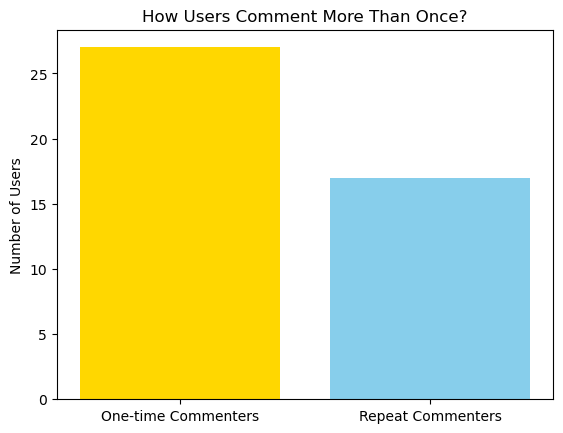

In [164]:
plt.bar(
    ['One-time Commenters', 'Repeat Commenters'],  
    [one_time, multi_time],                        
    color=['gold', 'skyblue']                    
)
plt.title("How Users Comment More Than Once?")
plt.ylabel("Number of Users")
plt.show()

# Final Results & Conclusion

## Hypothesis Evaluation
**My Hypothesis was wrong!** I am really surprised that I have more one-time commenters than repeat commenters. 

* **Initial Prediction:** I figured since most of my friends comment on my posts that there would be more repeat commenters, but I am wrong. 
* **Post-Analysis Reflection:** If I had to guess why I'm wrong, I'd say that there are a ton of people I have posted with in group photos that I am sort of friends with, but not on the level of friends where they comment on my other posts that they are not tagged in!